# Milestone 1: Formula 1 podium prediction

**Course:** CSEN 903 Advanced Computer Lab, GUC, Winter 2026

**Team:**

**The question we answer:** for one driver in one race, will he finish in the top 3?

**When we answer it:** after qualifying and before the race starts. This moment is our *cutoff*. Anything recorded after it (finishing position, points, laps, pit stops, status, updated standings) is the answer sheet of the exam. If the model sees it, that is *data leakage* and the scores mean nothing.

**How this notebook is organised**

| Section | What happens | Brief objective |
|---|---|---|
| 0 | Setup and loading | Run-all requirement |
| 1 | Audit and EDA before cleaning | 1 |
| 2 | Cleaning, then EDA again | 1 |
| 3 | One joined table, one row per driver per race | 1 |
| 4 | The three data-engineering questions | 2 |
| 5 | Feature engineering with leakage tests | 3 |
| 6 | Split, preprocessing, order experiments | 3 |
| 7 | Models and evaluation | 4 |
| 8 | Feature-group ablation | 5 |
| 9 | Explainability (permutation importance, SHAP, LIME) | 6 |
| 10 | Inference function | Deliverable 7 |
| 11 | Summary, limitations, checklist | Report |

Every section follows the same pattern: what we do, why we do it, the code, then what we see in the output.

In [1]:
# --- Standard libraries ---
import os, sys, glob, random, hashlib, warnings, subprocess, importlib, time
warnings.filterwarnings('ignore')                      # keep the notebook output readable

# --- Data and plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display


# --- Machine learning ---
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, confusion_matrix,
                             roc_curve, precision_recall_curve)

# --- Neural network ---
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')   # hide TensorFlow start-up messages
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


# --- Explainability ---
import shap
import lime.lime_tabular

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

# --- Reproducibility: one seed for everything ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print('pandas', pd.__version__, '| numpy', np.__version__, '| tensorflow', tf.__version__, '| shap', shap.__version__)

pandas 2.3.3 | numpy 2.1.3 | tensorflow 2.20.0 | shap 0.52.0


In [2]:
# --- One plotting style for the whole notebook, so every chart reads the same way ---
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'     # main colours, used in this fixed order
LIGHT_BLUE, GREY, RED = '#9ec5f4', '#9a9a95', '#d03b3b'  # "before / reference", neutral, warning

plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e6e3', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.frameon': False,
})

FIG_DIR = 'figures'              # every chart is also saved here, ready for the PDF report
os.makedirs(FIG_DIR, exist_ok=True)

def finish(fig, name):
    """Tidy the layout, save the chart as a PNG, and show it."""
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, name + '.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def pct(x, digits=1):
    """Format a share as a percentage string."""
    return f'{100 * x:.{digits}f}%'

In [3]:
import os
import pandas as pd

# The Kaggle dataset path
DATA_DIR = '/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020'

# The 14 table names
TABLES = [
    'circuits', 'constructors', 'constructor_results', 'constructor_standings', 
    'drivers', 'driver_standings', 'races', 'results', 'qualifying', 
    'lap_times', 'pit_stops', 'sprint_results', 'seasons', 'status'
]

# Load all tables into a dictionary as strings
raw = {}
for t in TABLES:
    file_path = os.path.join(DATA_DIR, t + '.csv')
    raw[t] = pd.read_csv(file_path, dtype=str, keep_default_na=False)

print('Successfully loaded tables:', len(raw))

Successfully loaded tables: 14


In [4]:
# To look at the first few rows of the drivers table
print(raw['drivers'].head())

# To look at the circuits table
print(raw['circuits'].head())

  driverId   driverRef number code  forename     surname         dob nationality                                             url
0        1    hamilton     44  HAM     Lewis    Hamilton  1985-01-07     British     http://en.wikipedia.org/wiki/Lewis_Hamilton
1        2    heidfeld     \N  HEI      Nick    Heidfeld  1977-05-10      German      http://en.wikipedia.org/wiki/Nick_Heidfeld
2        3     rosberg      6  ROS      Nico     Rosberg  1985-06-27      German       http://en.wikipedia.org/wiki/Nico_Rosberg
3        4      alonso     14  ALO  Fernando      Alonso  1981-07-29     Spanish    http://en.wikipedia.org/wiki/Fernando_Alonso
4        5  kovalainen     \N  KOV    Heikki  Kovalainen  1981-10-19     Finnish  http://en.wikipedia.org/wiki/Heikki_Kovalainen
  circuitId   circuitRef                            name      location    country       lat      lng  alt                                                url
0         1  albert_park  Albert Park Grand Prix Circuit     Melbourn

# 1. Audit and EDA before cleaning
Before we change anything we want to answer a very basic question: **"WHAT EXACTLY IS IN THE DATASET FILES AND WHAT IS WRONG WITH THESE FILES ?"**. Since EDA cannot be done by looking at the data by eye, so every statement in this section comes from code and has a table or a chart.

## 1.1 What do the 14 tables look like?
**What we do**: count rows and columns per table, and count the two kinds of placeholder for "missing": the text \N and the empty string.

**Why**: this tells us where the data lives (which tables are big), which tables need cleaning, and which table might be potentially our modelling table.

,table,rows,columns,cells equal to \N,empty cells
0,lap_times,589081,6,0,0
1,driver_standings,34863,7,0,0
2,results,26759,18,122887,0
3,constructor_standings,13391,7,0,0
4,constructor_results,12625,5,12608,0
5,pit_stops,11371,7,0,0
6,qualifying,10494,9,11600,68
7,races,1125,18,11349,0
8,drivers,861,9,1559,0
9,sprint_results,360,16,73,0


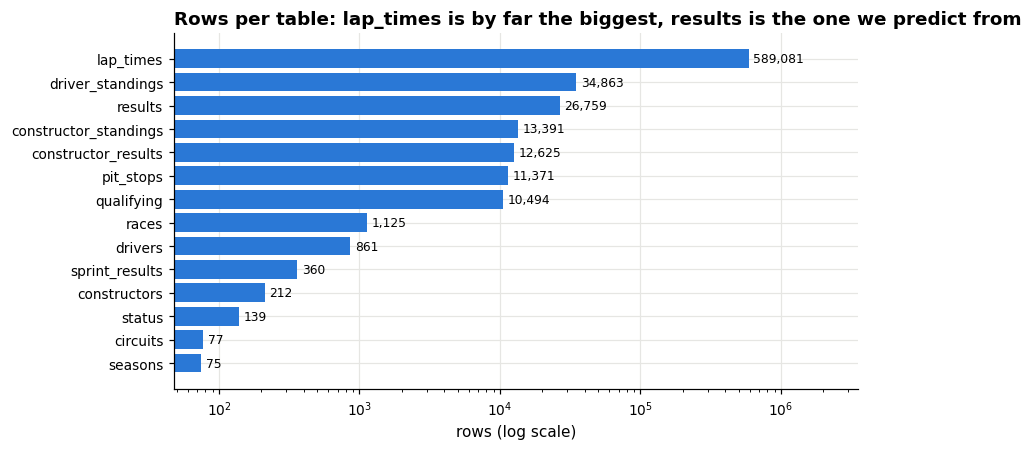

In [5]:
# One line per table: its size and how many placeholder cells it contains
overview = pd.DataFrame([{
    'table': t,
    'rows': len(df),
    'columns': df.shape[1],
    r'cells equal to \N': int((df == '\\N').sum().sum()),
    'empty cells': int((df == '').sum().sum()),
} for t, df in raw.items()]).sort_values('rows', ascending=False).reset_index(drop=True)
display(overview)

# Bar chart of the table sizes. The axis is logarithmic because lap_times is about 20 times bigger than results
fig, ax = plt.subplots(figsize=(8, 4.2))
o = overview.sort_values('rows')
bars = ax.barh(o['table'], o['rows'], color=BLUE)
ax.set_xscale('log')
ax.bar_label(bars, labels=[f'{v:,}' for v in o['rows']], padding=3, fontsize=8)
ax.set_xlabel('rows (log scale)')
ax.set_title('Rows per table: lap_times is by far the biggest, results is the one we predict from')
ax.set_xlim(right=o['rows'].max() * 6)
finish(fig, '01_rows_per_table')

## 1.2 How the tables link together

Now that subsection 1.1 told us what tables exist and how large they are, subsection 1.2 answers the next critical question: 
"**HOW ARE THESE 14 TABLES CONNECTED TO EACH OTHER ?**" 
This is exactly what we are answering in this subsection. 

**Why:** We know that the data is relational. Before joining we need to know which column identifies a row in each table (its primary key) and which columns point to another table (foreign keys). We write both down once, here, and the table below is our map for the rest of the notebook.

This is extremely important because our final modeling dataset will have to combine information from several tables. If we don't understand the keys and relationships first, we can easily create incorrect joins, duplicate rows, or lose observations.

In [6]:
# Primary key of every table, and every foreign key (child column -> parent table)
PRIMARY_KEYS = {
    'circuits': ['circuitId'], 'constructors': ['constructorId'], 'drivers': ['driverId'],
    'races': ['raceId'], 'seasons': ['year'], 'status': ['statusId'],
    'results': ['resultId'], 'qualifying': ['qualifyId'], 'sprint_results': ['resultId'],
    'driver_standings': ['driverStandingsId'], 'constructor_standings': ['constructorStandingsId'],
    'constructor_results': ['constructorResultsId'],
    'lap_times': ['raceId', 'driverId', 'lap'],      # composite key: no single id column
    'pit_stops': ['raceId', 'driverId', 'stop'],     # composite key
}
FOREIGN_KEYS = [  # (child table, column, parent table)
    ('races', 'circuitId', 'circuits'), ('races', 'year', 'seasons'),
    ('results', 'raceId', 'races'), ('results', 'driverId', 'drivers'),
    ('results', 'constructorId', 'constructors'), ('results', 'statusId', 'status'),
    ('qualifying', 'raceId', 'races'), ('qualifying', 'driverId', 'drivers'), ('qualifying', 'constructorId', 'constructors'),
    ('sprint_results', 'raceId', 'races'), ('sprint_results', 'driverId', 'drivers'),
    ('sprint_results', 'constructorId', 'constructors'), ('sprint_results', 'statusId', 'status'),
    ('driver_standings', 'raceId', 'races'), ('driver_standings', 'driverId', 'drivers'),
    ('constructor_standings', 'raceId', 'races'), ('constructor_standings', 'constructorId', 'constructors'),
    ('constructor_results', 'raceId', 'races'), ('constructor_results', 'constructorId', 'constructors'),
    ('lap_times', 'raceId', 'races'), ('lap_times', 'driverId', 'drivers'),
    ('pit_stops', 'raceId', 'races'), ('pit_stops', 'driverId', 'drivers'),
]

# The same information as one readable table: for each table, its key and the tables it points to
key_map = pd.DataFrame({
    'primary key': {t: ' + '.join(key) for t, key in PRIMARY_KEYS.items()},
    'points to (foreign keys)': {t: ', '.join(parent for child, _, parent in FOREIGN_KEYS if child == t) or '(nothing)' for t in PRIMARY_KEYS},
})
display(key_map)

,primary key,points to (foreign keys)
circuits,circuitId,(nothing)
constructors,constructorId,(nothing)
drivers,driverId,(nothing)
races,raceId,"circuits, seasons"
seasons,year,(nothing)
status,statusId,(nothing)
results,resultId,"races, drivers, constructors, status"
qualifying,qualifyId,"races, drivers, constructors"
sprint_results,resultId,"races, drivers, constructors, status"
driver_standings,driverStandingsId,"races, drivers"


**How to read it:** For example, `results` points to `races`, `drivers`, `constructors` and `status`. So one result row tells us which race, which driver, which team and how the race ended, but only as id numbers. The names and dates live in those four tables, and that is why we need joins. `races` in turn points to `circuits`, which is the "multi-hop" join: results to races to circuits.

## 1.3 Missing values: where and why

**What we do:** In this subsection, we answer a very important question: **"Where exactly are the missing values, how common are they, and most importantly are they missing randomly or for a reason?"**. So, for every column that contains a placeholder, compute the share of rows that are missing.

**Why:** a missing value can mean very different things. Sometimes the fact does not exist (a driver who retired has no finishing time). Sometimes the fact was never recorded (old seasons). We need to know which, because it decides how we treat it later. 

So, we're trying to distinguish:

*Missing because something wasn't recorded*

        vs.
*Missing because the value genuinely doesn't exist*

        vs.
*Missing because of historical/data-format differences*

Columns with at least one placeholder: 30


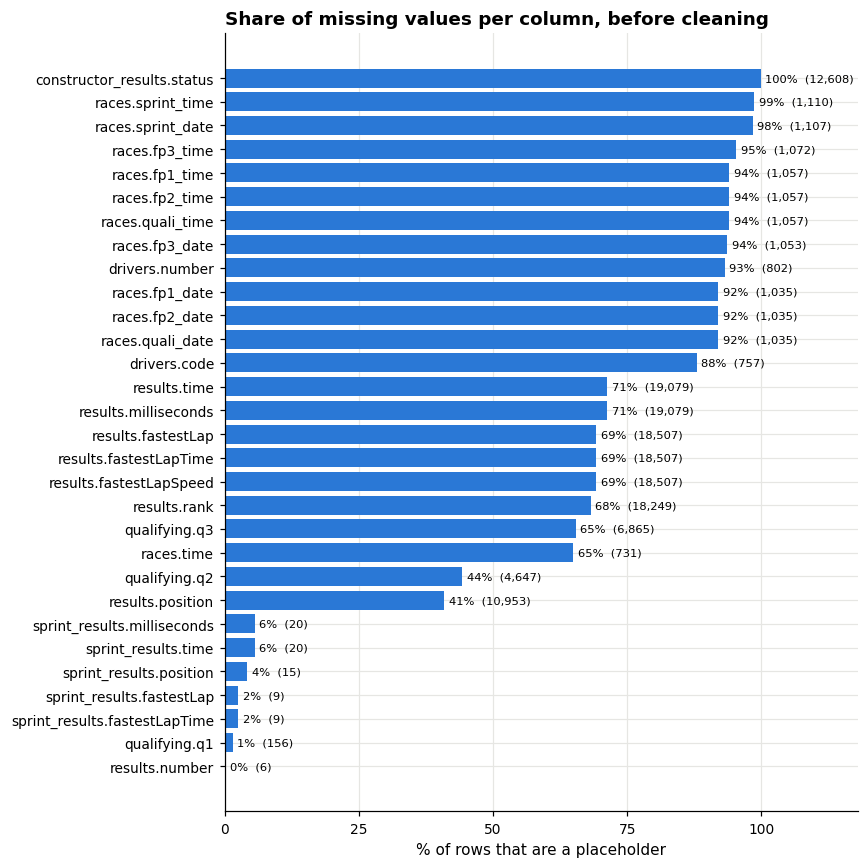

In [7]:
# For every column of every table: how many cells are a placeholder (\N or empty)?
missing_rows = []
for t, df in raw.items():
    for c in df.columns:
        n = int((df[c] == '\\N').sum() + (df[c] == '').sum())
        if n:
            missing_rows.append({'table': t, 'column': c, 'missing': n, 'share': n / len(df)})
missing_before = pd.DataFrame(missing_rows).sort_values('share')
print('Columns with at least one placeholder:', len(missing_before))

# One bar per column that has placeholders, labelled with the share and the count
fig, ax = plt.subplots(figsize=(8, 8))
labels = missing_before['table'] + '.' + missing_before['column']
bars = ax.barh(labels, missing_before['share'] * 100, color=BLUE)
ax.bar_label(bars, labels=[f'{s:.0%}  ({n:,})' for s, n in zip(missing_before['share'], missing_before['missing'])],
             padding=3, fontsize=7.5)
ax.set_xlim(0, 118); ax.set_xticks([0, 25, 50, 75, 100]); ax.set_xlabel('% of rows that are a placeholder')
ax.set_title('Share of missing values per column, before cleaning')
finish(fig, '03_missing_per_column')